<a href="https://colab.research.google.com/github/kyle-g-stubblefield/think-python/blob/main/advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can order print and ebook versions of *Think Python 3e* from
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) and
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [38]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

In [39]:
pip install colorama

In [168]:
"""
diku_color.py
─────────────
Converts Diku/ROM/SMAUG-style color codes to ANSI escape sequences,
with a Colab-aware HTML renderer that matches the classic xterm 16-color
dark-terminal palette exactly.

Usage:
    cprint("&+cAshenmoor&N -- &Rwarning&N!")

    In a real terminal  → ANSI escape codes
    In Colab / Jupyter  → HTML with CSS colors on a black background,
                          matching xterm/PuTTY dark-terminal colors

Color codes:
    &N / &n   reset
    &r / &R   dark red      / bright red
    &g / &G   dark green    / bright green
    &b / &B   dark blue     / bright blue
    &c / &C   dark cyan     / bright cyan
    &y / &Y   dark yellow   / bright yellow
    &m / &M   dark magenta  / bright magenta
    &w / &W   dark grey     / bright white
    &x / &X   black         / dark grey
    &+X       same as uppercase (explicit bright-bit prefix)
    &&        literal ampersand
"""

import re

# ── ANSI escape helpers ───────────────────────────────────────────────────────

RESET = "\033[0m"

def _ansi(code: int, bold: bool = False) -> str:
    return f"\033[1;{code}m" if bold else f"\033[{code}m"

_BARE = {
    "x": (30, False),  "X": (30, True),
    "r": (31, False),  "R": (31, True),
    "g": (32, False),  "G": (32, True),
    "y": (33, False),  "Y": (33, True),
    "b": (34, False),  "B": (34, True),
    "m": (35, False),  "M": (35, True),
    "c": (36, False),  "C": (36, True),
    "w": (37, False),  "W": (37, True),
}
_PLUS = {ch.lower(): (code, True) for ch, (code, _) in _BARE.items()}
_PLUS.update({ch.upper(): (code, True) for ch, (code, _) in _BARE.items()})


# ── Classic xterm 16-color palette (dark background) ─────────────────────────
#
# These are the standard hex values used by xterm, PuTTY, and most
# Linux terminal emulators. They're what players would have seen on a
# real Diku MUD in the 90s. Colab dark mode background is very close
# to #0d1117 so these read almost identically to a real terminal.
#
#   Index  ANSI  Color            Normal      Bright
#     0    30    black            #000000     #555555
#     1    31    red              #AA0000     #FF5555
#     2    32    green            #00AA00     #55FF55
#     3    33    yellow           #AA5500     #FFFF55
#     4    34    blue             #0000AA     #5555FF
#     5    35    magenta          #AA00AA     #FF55FF
#     6    36    cyan             #00AAAA     #55FFFF
#     7    37    white            #AAAAAA     #FFFFFF

_XTERM_PALETTE = {
    #        (ansi_code, bold)  ->  hex color
    (30, False): "#000000",   # black
    (30, True):  "#555555",   # dark grey
    (31, False): "#AA0000",   # dark red
    (31, True):  "#FF5555",   # bright red
    (32, False): "#00AA00",   # dark green
    (32, True):  "#55FF55",   # bright green
    (33, False): "#AA5500",   # dark yellow / olive
    (33, True):  "#FFFF55",   # bright yellow
    (34, False): "#0000AA",   # dark blue
    (34, True):  "#5555FF",   # bright blue
    (35, False): "#AA00AA",   # dark magenta
    (35, True):  "#FF55FF",   # bright magenta
    (36, False): "#00AAAA",   # dark cyan
    (36, True):  "#55FFFF",   # bright cyan
    (37, False): "#AAAAAA",   # dark white / grey
    (37, True):  "#FFFFFF",   # bright white
}


# ── Token parser (shared by both renderers) ───────────────────────────────────

def _tokenize(text: str):
    """
    Yield (kind, value) tuples:
        ("text",   str)
        ("color",  (ansi_code, bold))
        ("reset",  None)
    """
    i = 0
    n = len(text)
    while i < n:
        if text[i] != "&":
            # collect a run of plain characters
            j = i + 1
            while j < n and text[j] != "&":
                j += 1
            yield ("text", text[i:j])
            i = j
            continue

        if i + 1 >= n:
            yield ("text", "&"); i += 1; continue

        ch = text[i + 1]

        if ch == "&":
            yield ("text", "&"); i += 2; continue

        if ch in ("N", "n"):
            yield ("reset", None); i += 2; continue

        if ch == "+" and i + 2 < n:
            entry = _PLUS.get(text[i + 2])
            if entry:
                yield ("color", entry); i += 3; continue
            yield ("text", "&"); i += 1; continue

        entry = _BARE.get(ch)
        if entry:
            yield ("color", entry); i += 2; continue

        yield ("text", "&"); i += 1


# ── ANSI renderer ─────────────────────────────────────────────────────────────

def diku_to_ansi(text: str) -> str:
    """Replace Diku color codes with ANSI escape sequences."""
    parts = []
    for kind, value in _tokenize(text):
        if kind == "text":
            parts.append(value)
        elif kind == "color":
            parts.append(_ansi(*value))
        elif kind == "reset":
            parts.append(RESET)
    return "".join(parts)


# ── HTML renderer (Colab / Jupyter) ──────────────────────────────────────────

def _html_escape(s: str) -> str:
    return s.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def diku_to_html(text: str, bg: str = "#0d0d0d") -> str:
    """
    Convert Diku color codes to an HTML snippet styled to match a classic
    dark-background terminal using the standard xterm 16-color palette.

    bg defaults to near-black (#0d0d0d), matching Colab dark mode.
    Pass bg=None to omit the wrapper div (embed in your own container).
    """
    DEFAULT_FG = "#AAAAAA"   # grey — same as a bare terminal prompt

    parts = []
    current_color = None    # None means "use default fg"

    def open_span(color_hex):
        return f'<span style="color:{color_hex}">'

    for kind, value in _tokenize(text):
        if kind == "text":
            txt = _html_escape(value).replace("\n", "<br>")
            if txt:
                if current_color:
                    parts.append(open_span(current_color))
                    parts.append(txt)
                    parts.append("</span>")
                else:
                    parts.append(f'<span style="color:{DEFAULT_FG}">{txt}</span>')

        elif kind == "color":
            current_color = _XTERM_PALETTE.get(value, DEFAULT_FG)

        elif kind == "reset":
            current_color = None

    inner = "".join(parts)

    if bg is None:
        return inner

    return (
        f'<div style="background:{bg}; font-family:\'Courier New\',monospace; '
        f'font-size:14px; padding:8px 12px; border-radius:4px; '
        f'line-height:1.5; white-space:pre-wrap;">'
        f'{inner}</div>'
    )


# ── cprint: auto-detects Colab vs real terminal ───────────────────────────────

def _in_notebook() -> bool:
    """True when running inside Jupyter / Colab."""
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except ImportError:
        return False


def cprint(*args, sep: str = " ", end: str = "\n") -> None:
    """
    Drop-in replacement for print() that colorizes Diku codes.

    Accepts any objects, exactly like print() — each argument is converted
    to a string via str(), joined with sep, then colorized for the current
    environment:

        Terminal   : ANSI escape codes
        Colab/Jupyter : HTML rendered via IPython.display

    This means __repr__ / __str__ methods can return raw Diku-coded strings
    and cprint() will handle the colorization automatically:

        class Room:
            def __str__(self):
                return "&+WTHE RUSTY FLAGON&N\\nSmoky and warm."

        cprint(room)          # works — no color() call needed inside __str__
        cprint(room, player)  # works — stringifies both, joins, colorizes
        cprint("&Rhp:&N", 42) # works — mixed types fine
    """
    text = sep.join(str(a) for a in args)
    if _in_notebook():
        from IPython.display import display, HTML
        display(HTML(diku_to_html(text)))
    else:
        print(diku_to_ansi(text) + RESET, end=end)


def cstrip(text: str) -> str:
    """Remove all Diku color codes, returning plain text."""
    return re.sub(r"&&|&[Nn]|&\+?[a-zA-Z]",
                  lambda m: "&" if m.group() == "&&" else "",
                  text)

def color(text: str) -> str:
  return diku_to_ansi(text) + RESET

class ColorString(str):
    """
    A str subclass returned by color(..., "html").

    Behaves exactly like a regular string in every context — concatenation,
    slicing, len(), storing in a variable — but adds two extras:

      _repr_html_()   Colab/Jupyter calls this automatically when the object
                      is the last expression in a cell, so it renders as
                      colored HTML without you doing anything special.

      .display()      Explicitly push the HTML to the Colab output cell.
                      Use this when the color() call is NOT the last
                      expression, e.g. inside a loop or function.

    Never pass to print() — print() always writes the raw string, bypassing
    the HTML renderer.  Use cprint() or .display() instead.
    """
    def _repr_html_(self):
        return str(self)

    def display(self):
        """Render this HTML string in the current Colab / Jupyter output cell."""
        from IPython.display import display as _display, HTML
        _display(HTML(str(self)))


def color(text: str, mode: str = "ansi") -> str:
    """
    Convert a Diku-colored string and return the result.

    Parameters
    ----------
    text : str
        String containing Diku color codes (&+c, &R, &N, etc.)
    mode : str
        "ansi"  (default)
            Returns a plain str with ANSI escape sequences.
            Correct output when passed to print() in a real terminal.

        "html"
            Returns a ColorString (str subclass) containing an HTML
            snippet with inline CSS colors on a dark background.

            DO NOT pass to print() — print() always writes raw text.
            Instead use one of:
              color(s, "html").display()        explicit render
              cprint(s)                         auto-detects env, always right
            Or let it be the last expression in a Colab cell and Colab
            renders it automatically via _repr_html_().

    Returns
    -------
    str or ColorString
        "ansi" mode  ->  plain str  (ANSI escapes inside)
        "html" mode  ->  ColorString  (HTML that auto-renders in Colab)

    Examples
    --------
        # terminal
        print(color("&+cHello&N world"))

        # Colab — three equivalent ways
        cprint("&+cHello&N world")                    # easiest, always correct
        color("&+cHello&N world", "html").display()   # explicit render
        color("&+cHello&N world", "html")             # last expression in cell
    """
    if mode == "html":
        return ColorString(diku_to_html(text))
    return diku_to_ansi(text) + RESET

In [185]:
# ── Demo (terminal mode) ──────────────────────────────────────────────────────

if __name__ == "__main__":
    samples = [
        "&+cAshenmoor&N -- a text adventure",
        "&Rwarning:&N health is &+Rcritically low&N!",
        "&+WTHE RUSTY FLAGON&N",
        "&YGold&N: 42  &wSilver&N: 7  &xCopper&N: 3",
        "&ggreen&N  &+Gbright green&N  &ccyan&N  &+cbright cyan&N",
        "&mmagenta&N  &Mbright magenta&N  &bblue&N  &Bbright blue&N",
        "&&N is a literal ampersand-N, not a reset",
    ]
    print("\n\033[1m-- terminal ANSI demo --\033[0m")
    for s in samples:
        print(f"  raw: {s}")
        cprint(f"  out: {s}")
        print()
    print("\033[1m-- cstrip --\033[0m")
    for s in samples:
        print(f"  {cstrip(s)}")


-- terminal ANSI demo --
  raw: &+cAshenmoor&N -- a text adventure



  raw: &Rwarning:&N health is &+Rcritically low&N!



  raw: &+WTHE RUSTY FLAGON&N



  raw: &YGold&N: 42  &wSilver&N: 7  &xCopper&N: 3



  raw: &ggreen&N  &+Gbright green&N  &ccyan&N  &+cbright cyan&N



  raw: &mmagenta&N  &Mbright magenta&N  &bblue&N  &Bbright blue&N



  raw: &&N is a literal ampersand-N, not a reset



-- cstrip --
  Ashenmoor -- a text adventure
  THE RUSTY FLAGON
  Gold: 42  Silver: 7  Copper: 3
  green  bright green  cyan  bright cyan
  magenta  bright magenta  blue  bright blue
  &N is a literal ampersand-N, not a reset


In [42]:
from colorama import Fore, Back, Style
from enum import Enum

class Stats(Enum):
  STRENGTH = 0
  DEXTERITY = 1
  CONSTITUTION = 2
  INTELLIGENCE = 3
  WISDOM = 4
  CHARISMA = 5

  @property
  def abv(self):
    return self.name.lower()[:3]

In [43]:
## Base Race Class
class Race():
  def __init__(self, d = {
      'stats_modifier': [1, 1, 1, 1, 1, 1],
      'innate_abilities': [],
      'size': 'medium'}, statlist = Stats):
    self.stats_modifiers = d['stats_modifier']

  def get_mod(self, stat):
    if type(stat) == int:
      return self.stats_modifiers[stat]
    elif type(stat) == str:
      for k in Stats:
        if stat == k.abv:
          return self.stats_modifiers[k.value]
    return None

In [44]:
## Base Character Class
class Character():
  """ Base character class """

  def __init__(self, d, statlist = Stats):
    self.name = d.get('name', None)
    self.stats = d.get('stats', [80,80,80,80,80,80])
    self.race = d.get('race', 'Human')
    self.level = d.get('level', 1)
    self.position = d.get('position', 'standing')
    self.cclass = d.get('class', 'Warrior')

  def __str__(self):
    self.pcs()


  def get_stat(self, stat):
    if type(stat) == int:
      return self.stats[stat]
    elif type(stat) == str:
      for k in Stats:
        if stat == k.abv:
          return self.stats[k.value]
    return None


  def computed_stat(self, stat):
    return int(self.get_stat(stat) * races[self.race].get_mod(stat))

  def pcs(self):
    print(f'Character sheet for {self.name}\n')
    print(f'Race: {self.race}')
    print(f'Class: {self.cclass}')
    print(f'Level: {self.level}')
    print(f'Stats:')
    print(f'Strength:     {self.get_stat('str'):>3}    Intelligence: {self.get_stat('int'):>3}')
    print(f'Dexterity:    {self.get_stat('dex'):>3}    Wisdom:       {self.get_stat('wis'):>3}')
    print(f'Constitution: {self.get_stat('con'):>3}    Charisma:     {self.get_stat('cha'):>3}')
    print('\n\n')

In [45]:
class Object():
  def __init__(self, d = {
      'name': None,
      'room_description': None,
      'key_words': (None),
      'description': None}):
    self.name = d['name']
    self.room_description = d['room_description']
    self.key_words = d['key_words']
    self.description = d['description']

In [169]:
terrain = ('no ground', 'water', 'mountain', 'plain', 'stone')

class Room():
  def __init__(self, d):
    self.number = d['number']
    self.name = d['name']
    self.description = d['description']
    self.indoors = d['indoors']
    self.terrain = d['terrain']
    self.exits = d['exits']
    self.objects = d['objects']

  def _exits(self):
    output = Fore.GREEN + "Exits:" + Style.RESET_ALL #\[033;0
    #output = "Exits:"
    if len(self.exits) == 0:
      output += Fore.LIGHTRED_EX + " None!" + Style.RESET_ALL #\[023;0
      #output += " None!"
    else:
      count = 0
      for exit in self.exits:
        output += Fore.CYAN
        if count > 0:
          output += " -"
        output += f' {exit['direction'].title()}'
        count += 1
    return output  + Style.RESET_ALL + "\n"
    #return output + "\n"

  def _objects(self):
    output = ""
    if len(self.objects) > 0:
      for obj in self.objects:
        output += f'{obj.room_description}\n'
    return output


  @property
  def characters(self):
    char = []
    for c, r in locations.items():
      if r == self.number:
        char.append(c)
    return char

  def _characters(self):
    output = ""
    if len(self.characters) > 0:
      for character in self.characters:
        output += f'{characters[character].name.title()} stands here\n'
    return output


  def __repr__(self):
    output = f'{self.name}\n     {self.description}\n'
    output += self._exits()
    output += self._objects()
    output += self._characters()
    return output

In [47]:
## Creates Race Instances
#from character import Character
#from race import Race


races = {}
races['Human'] = Race()
races['Dwarf'] = Race({'stats_modifier': [1.1, 1, 1.3, .9, 1, 10], 'size': 'medium_small', 'innate_abilities': ['infravision']})
races['Grey Elf'] = Race({'stats_modifier': [.7, 1.2, .8, 1.1, 1, 1.1], 'size': 'medium_small', 'innate_abilities': ['infravision', 'outdoor_sneak']})
races['Ogre'] = Race({'stats_modifier': [1.5, .8, 1.5, .5, .75, .75], 'size': 'large' ,'innate_abilities': ['doorbash']})

## Create a moted Instance
characters = {}
characters['Moted'] = Character({
    'name': "Moted",
    'race': 'Dwarf',
    'class': 'Shaman',
    'level': 24,
    "stats": [88, 80, 80, 80, 80, 80]})
characters['Aleolas'] = Character({
    'name': "Aleolas",
    'race': 'Grey Elf',
    'class': 'Ranger',
    'level': 50,
    "stats": [100, 80, 100, 80, 80, 80]})
characters['Illilel'] = Character({
    'name': "Illilel",
    'race': "Grey Elf",
    'class': "Bard",
    'level': 50,
    'stats': [100, 100, 100, 72, 54, 100]
})

def character_list(char_list):
  print(f'{"Name":<15} {"Race":<12} {"Class":<10} {"Level":>2}')
  print("_" * 45, end="\n\n")

  for (_, char) in char_list.items():
    print(f'{char.name:<15} {char.race:<12} {char.cclass:<10} {char.level:>5}')

character_list(characters)

Name            Race         Class      Level
_____________________________________________

Moted           Dwarf        Shaman        24
Aleolas         Grey Elf     Ranger        50
Illilel         Grey Elf     Bard          50


In [48]:
print(characters['Moted'].get_stat('con'))
print(characters['Moted'].computed_stat('con'))

80
104


In [174]:
rooms = {}
objects = []

tss = {
    'name': "a &+rtattered &+csilken sack&N",
    'key_words': ('tattered', 'silken', 'sack'),
    'room_description': "a &+rtattered &+csilken sack&N lies here, discarded.",
    'description': "This sack seems in a awful condition, large holes open in its silken\nfabric but strangely enough nothing exits from them."
}
windsong = {
    'room_description': "&+ga &wg&Wl&wi&Wtt&wer&Wi&wng &N&+gelven scimitar&N",
    'name': "&+gA glittering elven scimitar is lying on the ground here.&N",
    'key_words': ('scimitar', 'elven', 'glittering'),
    'description': """&+gIts blade encrusted with diamond dust, this magically light
&+gelven blade glitters in the sunlight and seems to hum softly
&+gwhen wielded in battle.&N"""
}
objects.append(Object(
    {'name': 'red expo marker',
     'key_words': ('red', 'expo', 'marker'),
     'room_description': 'a red expo marker is carlessly discarded here',
     'description': 'Dark magenta low scent marker, half used'}
    ))

objects.append(Object(
    {'name': 'green expo marker',
     'key_words': ('green', 'expo', 'marker'),
     'room_description': 'a green expo marker is carlessly discarded here',
     'description': 'Forest green low scent marker, half used'}))

rooms[1] = Room({
    'number': 1,
    'name': 'The Void',
    'description': 'There is nothing here but the sound of rushing of wind.\nWe are waiting for the Spirit of God to move over it.',
    'indoors': False,
    'terrain': 'no ground',
    'exits': [
        {'direction': "north", "roomId": 1},
        {'direction': "south", "roomId": 1},
        {'direction': "east", "roomId": 2},
        {'direction': "west", "roomId": 1},
        {'direction': "up", "roomId": 1},
        {'direction': "down", "roomId": 1}
        ],
    'objects':[]})

rooms[2] = Room({
    'number': 2,
    'name': 'Not The Void',
    'description': 'You left\nSo sorry',
    'indoors': False,
    'terrain': 'no ground',
    'exits': [
        {'direction': "north", "roomId": 1},
        {'direction': 'south', 'roomId': 3}
        ],
    'objects': [*objects]})

rooms[3] = Room({
    'number': 3,
    'name': 'Not the Not The Void',
    'description': 'This is getting silly\ncarry on',
    'indoors': False,
    'terrain': 'no ground',
    'exits': [
        {'direction': "north", "roomId": 2},
        {'direction': 'west', 'roomId': 3},
        {'direction': 'east', 'roomId': 1}
        ],
    'objects': []})

ptr = Object(tss)
objects.append(ptr)
rooms[2].objects.append(ptr)
ptr = Object(windsong)
objects.append(ptr)
rooms[2].objects.append(ptr)

#print(here)
locations = {'Moted': 1,
    'Illilel': 1,
    'Aleolas': 1}

In [50]:
for c, r in locations.items():
  print(c)

Moted
Illilel
Aleolas


In [177]:
def go(character, locations, rooms, direction):
  #print(rooms[positions[character]])
  cprint(direction)
  room = rooms[locations[character]]

  #loop over the exits in the room
  for rm in room.exits:
    if rm['direction'] == direction:
      rmid = rm['roomId']
      cprint(rooms[rmid])
      locations[character] = rmid


      #cuts the loop short if found
      return

  #sanity check, exit not found print alas
  cprint("Alas, you cannot go that way. . . .")

In [184]:
go('Moted', locations, rooms, 'east')
print(locations)


{'Moted': 2, 'Illilel': 1, 'Aleolas': 1}


In [53]:
## Create a new room instance
## name description and at least 1 exit

## Create a new object instance

## Create a new character instance

In [54]:
print(objects)

def get_object(key_word, objects):
  for obj in objects:
    if key_word in obj.key_words:
      return obj
  return None

marker = get_object('green', objects)
print(marker)

[<__main__.Object object at 0x7e54bd0b62a0>, <__main__.Object object at 0x7e54bd0b4950>]


# Classes and Functions

At this point you know how to use functions to organize code and how to use built-in types to organize data.
The next step is **object-oriented programming**, which uses programmer-defined types to organize both code and data.

Object-oriented programming is a big topic, so we will proceed gradually.
In this chapter, we'll start with code that is not idiomatic -- that is, it is not the kind of code experienced programmers write -- but it is a good place to start.
In the next two chapters, we will use additional features to write more idiomatic code.

## Programmer-defined types

We have used many of Python's built-in types -- now we will define a new type.
As a first example, we'll create a type called `Time` that represents a time of day.
A programmer-defined type is also called a **class**.
A class definition looks like this:

In [55]:
class Time:
    """Represents a time of day."""

The header indicates that the new class is called `Time`.
The body is a docstring that explains what the class is for.
Defining a class creates a **class object**.

The class object is like a factory for creating objects.
To create a `Time` object, you call `Time` as if it were a function.

In [56]:
lunch = Time()

The result is a new object whose type is `__main__.Time`, where `__main__` is the name of the  module where `Time` is defined.

In [57]:
type(lunch)

__main__.Time

When you print an object, Python tells you what type it is and where it is stored in memory (the prefix `0x` means that the following number is in hexadecimal).

In [58]:
print(lunch)

Creating a new object is called **instantiation**, and the object is an **instance** of the class.

## Attributes

An object can contain variables, which are called **attributes** and pronounced with the emphasis on the first syllable, like "AT-trib-ute", rather than the second syllable, like "a-TRIB-ute".
We can create attributes using dot notation.

In [59]:
lunch.hour = 11
lunch.minute = 59
lunch.second = 1

This example creates attributes called `hour`, `minute`, and `second`, which contain the hours, minutes, and seconds of the time `11:59:01`, which is lunch time as far as I am concerned.

The following diagram shows the state of `lunch` and its attributes after these assignments.

In [60]:
from diagram import make_frame, make_binding

d1 = dict(hour=11, minute=59, second=1)
frame = make_frame(d1, name='Time', dy=-0.3, offsetx=0.48)
binding = make_binding('lunch', frame)

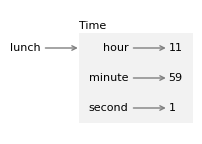

In [61]:
from diagram import diagram, adjust

width, height, x, y = [1.77, 1.24, 0.25, 0.86]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

The variable `lunch` refers to a `Time` object, which contains three attributes.
Each attribute refers to an integer.
A state diagram like this -- which shows an object and its attributes -- is called an **object diagram**.

You can read the value of an attribute using the dot operator.

In [62]:
lunch.hour

11

You can use an attribute as part of any expression.

In [63]:
total_minutes = lunch.hour * 60 + lunch.minute
total_minutes

719

And you can use the dot operator in an expression in an f-string.

In [64]:
f'{lunch.hour}:{lunch.minute}:{lunch.second}'

'11:59:1'

But notice that the previous example is not in the standard format.
To fix it, we have to print the `minute` and `second` attributes with a leading zero.
We can do that by extending the expressions in curly braces with a **format specifier**.
In the following example, the format specifiers indicate that `minute` and `second` should be displayed with at least two digits and a leading zero if needed.

In [65]:
f'{lunch.hour}:{lunch.minute:02d}:{lunch.second:02d}'

'11:59:01'

We'll use this f-string to write a function that displays the value of a `Time`object.
You can pass an object as an argument in the usual way.
For example, the following function takes a `Time` object as an argument.

In [66]:
def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

When we call it, we can pass `lunch` as an argument.

In [67]:
print_time(lunch)

11:59:01


## Objects as return values

Functions can return objects. For example, `make_time` takes parameters called `hour`, `minute`, and `second`, stores them as attributes in a `Time` object, and returns the new object.

In [68]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

It might be surprising that the parameters have the same names as the attributes, but that's a common way to write a function like this.
Here's how we use `make_time` to create a `Time` object.

In [69]:
time = make_time(11, 59, 1)
print_time(time)

11:59:01


## Objects are mutable

Suppose you are going to a screening of a movie, like *Monty Python and the Holy Grail*, which starts at `9:20 PM` and runs for `92` minutes, which is one hour `32` minutes.
What time will the movie end?

First, we'll create a `Time` object that represents the start time.

In [70]:
start = make_time(9, 20, 0)
print_time(start)

09:20:00


To find the end time, we can modify the attributes of the `Time` object, adding the duration of the movie.

In [71]:
start.hour += 1
start.minute += 32
print_time(start)

10:52:00


The movie will be over at 10:52 PM.

Let's encapsulate this computation in a function and generalize it to take the duration of the movie in three parameters: `hours`, `minutes`, and `seconds`.

In [72]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

Here is an example that demonstrates the effect.

In [73]:
start = make_time(9, 20, 0)
increment_time(start, 1, 32, 0)
print_time(start)

10:52:00


The following stack diagram shows the state of the program just before `increment_time` modifies the object.

In [74]:
from diagram import Frame, Binding, Value, Stack

d1 = dict(hour=9, minute=20, second=0)
obj1 = make_frame(d1, name='Time', dy=-0.25, offsetx=0.78)

binding1 = make_binding('start', frame, draw_value=False, dx=0.7)
frame1 = Frame([binding1], name='__main__', loc='left', offsetx=-0.2)

binding2 = Binding(Value('time'), draw_value=False, dx=0.7, dy=0.35)
binding3 = make_binding('hours', 1)
binding4 = make_binding('minutes',32)
binding5 = make_binding('seconds', 0)
frame2 = Frame([binding2, binding3, binding4, binding5], name='increment_time',
               loc='left', dy=-0.25, offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

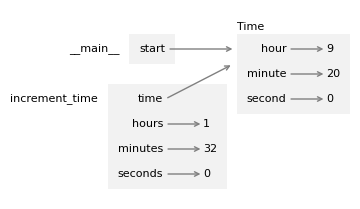

In [75]:
from diagram import Bbox

width, height, x, y = [3.4, 1.89, 1.75, 1.5]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = obj1.draw(ax, x+0.23, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Inside the function, `time` is an alias for `start`, so when `time` is modified, `start` changes.

This function works, but after it runs, we're left with a variable named `start` that refers to an object that represents the *end* time, and we no longer have an object that represents the start time.
It would be better to leave `start` unchanged and make a new object to represent the end time.
We can do that by copying `start` and modifying the copy.

## Copying

The `copy` module provides a function called `copy` that can duplicate any object.
We can import it like this.

In [76]:
from copy import copy

To see how it works, let's start with a new `Time` object that represents the start time of the movie.

In [77]:
start = make_time(9, 20, 0)

And make a copy.

In [78]:
end = copy(start)

Now `start` and `end` contain the same data.

In [79]:
print_time(start)
print_time(end)

09:20:00
09:20:00


But the `is` operator confirms that they are not the same object.

In [80]:
start is end

False

Let's see what the `==` operator does.

In [81]:
start == end

False

You might expect `==` to yield `True` because the objects contain the same data.
But for programmer-defined classes, the default behavior of the `==` operator is the same as the `is` operator -- it checks identity, not equivalence.

## Pure functions

We can use `copy` to write pure functions that don't modify their parameters.
For example, here's a function that takes a `Time` object and a duration in hours, minutes and seconds.
It makes a copy of the original object, uses `increment_time` to modify the copy, and returns it.

In [82]:
def add_time(time, hours, minutes, seconds):
    total = copy(time)
    increment_time(total, hours, minutes, seconds)
    return total

Here's how we use it.

In [83]:
end = add_time(start, 1, 32, 0)
print_time(end)

10:52:00


The return value is a new object representing the end time of the movie.
And we can confirm that `start` is unchanged.

In [84]:
print_time(start)

09:20:00


`add_time` is a **pure function** because it does not modify any of the objects passed to it as arguments and its only effect is to return a value.

Anything that can be done with impure functions can also be done with pure functions.
In fact, some programming languages only allow pure functions.
Programs that use pure functions might be less error-prone, but impure functions are sometimes convenient and can be more efficient.

In general, I suggest you write pure functions whenever it is reasonable and resort to impure functions only if there is a compelling advantage.
This approach might be called a **functional programming style**.

## Prototype and patch

In the previous example, `increment_time` and `add_time` seem to work, but if we try another example, we'll see that they are not quite correct.

Suppose you arrive at the theater and discover that the movie starts at `9:40`, not `9:20`.
Here's what happens when we compute the updated end time.

In [85]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

10:72:00


The result is not a valid time.
The problem is that `increment_time` does not deal with cases where the number of seconds or minutes adds up to more than `60`.

Here's an improved version that checks whether `second` exceeds or equals `60` -- if so, it increments `minute` -- then checks whether `minute` exceeds or equals `60` -- if so, it increments `hour`.

In [86]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    if time.second >= 60:
        time.second -= 60
        time.minute += 1

    if time.minute >= 60:
        time.minute -= 60
        time.hour += 1

Fixing `increment_time` also fixes `add_time`, which uses it.
So now the previous example works correctly.

In [87]:
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


But this function is still not correct, because the arguments might be bigger than `60`.
For example, suppose we are given the run time as `92` minutes, rather than `1` hours and `32` minutes.
We might call `add_time` like this.

In [88]:
end = add_time(start, 0, 92, 0)
print_time(end)

10:72:00


The result is not a valid time.
So let's try a different approach, using the `divmod` function.
We'll make a copy of `start` and modify it by incrementing the `minute` attribute.

In [89]:
end = copy(start)
end.minute = start.minute + 92
end.minute

132

Now `minute` is `132`, which is `2` hours and `12` minutes.
We can use `divmod` to divide by `60` and return the number of whole hours and the number of minutes left over.

In [90]:
carry, end.minute = divmod(end.minute, 60)
carry, end.minute

(2, 12)

Now `minute` is correct, and we can add the hours to `hour`.

In [91]:
end.hour += carry
print_time(end)

11:12:00


The result is a valid time.
We can do the same thing with `hour` and `second`, and encapsulate the whole process in a function.

In [92]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    carry, time.second = divmod(time.second, 60)
    carry, time.minute = divmod(time.minute + carry, 60)
    carry, time.hour = divmod(time.hour + carry, 24)

With this version of `increment_time`, `add_time` works correctly, even if the arguments exceed `60`.

In [93]:
end = add_time(start, 0, 90, 120)
print_time(end)

11:12:00


This section demonstrates a program development plan I call **prototype and patch**.
We started with a simple prototype that worked correctly for the first example.
Then we tested it with more difficult examples -- when we found an error, we modified the program to fix it, like putting a patch on tire with a puncture.

This approach can be effective, especially if you don't yet have a deep understanding of the problem.
But incremental corrections can generate code that is unnecessarily complicated -- since it deals with many special cases -- and unreliable -- since it is hard to know if you have
found all the errors.

## Design-first development

An alternative plan is **design-first development**, which involves more planning before prototyping. In a design-first process, sometimes a high-level insight into the problem makes the programming much easier.

In this case, the insight is that we can think of a `Time` object as a three-digit number in base 60 -- also known as sexagesimal.
The `second` attribute is the "ones column", the `minute` attribute is the "sixties column",
and the `hour` attribute is the "thirty-six hundreds column".
When we wrote `increment_time`, we were effectively doing addition in base 60, which is why we had to carry from one column to the next.

This observation suggests another approach to the whole problem -- we can convert `Time` objects to integers and take advantage of the fact that Python knows how to do integer arithmetic.

Here is a function that converts from a `Time` to an integer.

In [94]:
def time_to_int(time):
    minutes = time.hour * 60 + time.minute
    seconds = minutes * 60 + time.second
    return seconds

The result is the number of seconds since the beginning of the day.
For example, `01:01:01` is `1` hour, `1` minute and `1` second from the beginning of the day, which is the sum of `3600` seconds, `60` seconds, and `1` second.

In [95]:
time = make_time(1, 1, 1)
print_time(time)
time_to_int(time)

01:01:01


3661

And here's a function that goes in the other direction -- converting an integer to a `Time` object -- using the `divmod` function.

In [96]:
def int_to_time(seconds):
    minute, second = divmod(seconds, 60)
    hour, minute = divmod(minute, 60)
    return make_time(hour, minute, second)

We can test it by converting the previous example back to a `Time`.

In [97]:
time = int_to_time(3661)
print_time(time)

01:01:01


Using these functions, we can write a more concise version of `add_time`.

In [98]:
def add_time(time, hours, minutes, seconds):
    duration = make_time(hours, minutes, seconds)
    seconds = time_to_int(time) + time_to_int(duration)
    return int_to_time(seconds)

The first line converts the arguments to a `Time` object called `duration`.
The second line converts `time` and `duration` to seconds and adds them.
The third line converts the sum to a `Time` object and returns it.

Here's how it works.

In [99]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


In some ways, converting from base 60 to base 10 and back is harder than
just dealing with times. Base conversion is more abstract; our intuition
for dealing with time values is better.

But if we have the insight to treat times as base 60 numbers -- and invest the effort to write the conversion functions `time_to_int` and `int_to_time` -- we get a program that is shorter, easier to read and debug, and more reliable.

It is also easier to add features later. For example, imagine subtracting two `Time` objects to find the duration between them.
The naive approach is to implement subtraction with borrowing.
Using the conversion functions is easier and more likely to be correct.

Ironically, sometimes making a problem harder -- or more general -- makes it easier, because there are fewer special cases and fewer opportunities for error.

## Debugging

Python provides several built-in functions that are useful for testing and debugging programs that work with objects.
For example, if you are not sure what type an object is, you can ask.

In [100]:
type(start)

__main__.Time

You can also use `isinstance` to check whether an object is an instance of a particular class.

In [101]:
isinstance(end, Time)

True

If you are not sure whether an object has a particular attribute, you
can use the built-in function `hasattr`.

In [102]:
hasattr(start, 'hour')

True

To get all of the attributes, and their values, in a dictionary, you can use `vars`.

In [103]:
vars(start)

{'hour': 9, 'minute': 40, 'second': 0}

The `structshape` module, which we saw in [Chapter 11](section_debugging_11), also works with programmer-defined types.

In [104]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/structshape.py');

Downloaded structshape.py


In [105]:
from structshape import structshape

t = start, end
structshape(t)

'tuple of 2 Time'

## Glossary

**object-oriented programming:**
A style of programming that uses objects to organize code and data.

**class:**
 A programmer-defined type. A class definition creates a new class object.

**class object:**
An object that represents a class -- it is the result of a class definition.

**instantiation:**
The process of creating an object that belongs to a class.

**instance:**
 An object that belongs to a class.

**attribute:**
 A variable associated with an object, also called an instance variable.

**object diagram:**
A graphical representation of an object, its attributes, and their values.

**format specifier:**
In an f-string, a format specifier determines how a value is converted to a string.

**pure function:**
A function that does not modify its parameters or have any effect other than returning a value.

**functional programming style:**
A way of programming that uses pure functions whenever possible.

**prototype and patch:**
A way of developing programs by starting with a rough draft and gradually adding features and fixing bugs.

**design-first development:**
A way of developing programs with more careful planning that prototype and patch.

## Exercises

In [106]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Ask a virtual assistant

There is a lot of new vocabulary in this chapter.
A conversation with a virtual assistant can help solidify your understanding.
Consider asking:

* "What is the difference between a class and a type?"

* "What is the difference between an object and an instance?"

* "What is the difference between a variable and an attribute?"

* "What are the pros and cons of pure functions compared to impure functions?"

Because we are just getting started with object oriented programming, the code in this chapter is not idiomatic -- it is not the kind of code experienced programmers write.
If you ask a virtual assistant for help with the exercises, you will probably see features we have not covered yet.
In particular, you are likely to see a method called `__init__` used to initialize the attributes of an instance.

If these features make sense to you, go ahead and use them.
But if not, be patient -- we will get there soon.
In the meantime, see if you can solve the following exercises using only the features we have covered so far.

Also, in this chapter we saw one example of a format specifier. For more information, ask "What format specifiers can be used in a Python f-string?"

### Exercise

Write a function called `subtract_time` that takes two `Time` objects and returns the interval between them in seconds -- assuming that they are two times during the same day.

Here's an outline of the function to get you started.

In [107]:
def subtract_time(t1, t2):
    """Compute the difference between two times in seconds.

    >>> subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))
    1
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))
    121
    >>> subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))
    5520
    """
    return None

In [108]:
# Solution goes here

You can use `doctest` to test your function.

In [109]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(subtract_time)

**********************************************************************
File "__main__", line 4, in subtract_time
Failed example:
    subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))
Expected:
    1
Got nothing
**********************************************************************
File "__main__", line 6, in subtract_time
Failed example:
    subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))
Expected:
    121
Got nothing
**********************************************************************
File "__main__", line 8, in subtract_time
Failed example:
    subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))
Expected:
    5520
Got nothing


### Exercise

Write a function called `is_after` that takes two `Time` objects and returns `True` if the first time is later in the day than the second, and `False` otherwise.

Here's an outline of the function to get you started.

In [110]:
def is_after(t1, t2):
    """Checks whether `t1` is after `t2`.

    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 0))
    True
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 1))
    False
    >>> is_after(make_time(11, 12, 0), make_time(9, 40, 0))
    True
    """
    return None

In [111]:
# Solution goes here

You can use `doctest` to test your function.

In [112]:
run_doctests(is_after)

**********************************************************************
File "__main__", line 4, in is_after
Failed example:
    is_after(make_time(3, 2, 1), make_time(3, 2, 0))
Expected:
    True
Got nothing
**********************************************************************
File "__main__", line 6, in is_after
Failed example:
    is_after(make_time(3, 2, 1), make_time(3, 2, 1))
Expected:
    False
Got nothing
**********************************************************************
File "__main__", line 8, in is_after
Failed example:
    is_after(make_time(11, 12, 0), make_time(9, 40, 0))
Expected:
    True
Got nothing


### Exercise

Here's a definition for a `Date` class that represents a date -- that is, a year, month, and day of the month.

In [113]:
class Date:
    """Represents a year, month, and day"""

1. Write a function called `make_date` that takes `year`, `month`, and `day` as parameters, makes a `Date` object, assigns the parameters to attributes, and returns the result the new object. Create an object that represents June 22, 1933.

2. Write a function called `print_date` that takes a `Date` object, uses an f-string to format the attributes, and prints the result. If you test it with the `Date` you created, the result should be `1933-06-22`.

3. Write a function called `is_after` that takes two `Date` objects as parameters and returns `True` if the first comes after the second. Create a second object that represents September 17, 1933, and check whether it comes after the first object.

Hint: You might find it useful to write a function called `date_to_tuple` that takes a `Date` object and returns a tuple that contains its attributes in year, month, day order.

You can use this function outline to get started.

In [114]:
def make_date(year, month, day):
    return None

In [115]:
# Solution goes here

You can use these examples to test `make_date`.

In [116]:
birthday1 = make_date(1933, 6, 22)

In [117]:
birthday2 = make_date(1933, 9, 17)

You can use this function outline to get started.

In [118]:
def print_date(date):
    print('')

In [119]:
# Solution goes here

You can use this example to test `print_date`.

In [120]:
print_date(birthday1)

You can use this function outline to get started.

In [121]:
def is_after(date1, date2):
    return None

In [122]:
# Solution goes here

In [123]:
# Solution goes here

You can use these examples to test `is_after`.

In [124]:
is_after(birthday1, birthday2)  # should be False

In [125]:
is_after(birthday2, birthday1)  # should be True

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)